# Ocean climatology maps — SST, SSS and AMOC (alternate spin-ups vs Full-CPL)

Figures:
* `ocn_map_compare_SST_SSS_AMOC_ANN.pdf` — **combined figure**: SST (a–c), SSS (d–f), AMOC (g–i)
* `mpaso_ANN_<clim>_climo.nc_compare_SST_ANN.pdf`, `…_compare_SSS_ANN.pdf`, `mocTimeSeries_compare_AMOC_ANN_climo_diff.pdf` — the three rows as separate figures
* `mocStreamfunction_compare_MOCGlobal_ANN_climo_diff.pdf` — global MOC (section 4, separate figure)

Differences from the reference (first of `EXPS`) are stippled where significant (`SIG_*` in Setup), with the same test in every panel: is the difference of two `CLIMO_LEN`-yr means larger than the differences between `CLIMO_LEN`-yr means of the piControl run (internal variability alone)? t = d / (s·√2), s = standard deviation of the non-overlapping piControl `CLIMO_LEN`-yr means at that point, df = n − 1 (two-sided, pointwise at `SIG_ALPHA`).

The derived-values cell checks that each experiment's MPAS-Analysis climatology really averages `CLIM_YEARS` (against its monthly MOC time series). Where it does not (FC-FOSI-S1/S2: MPAS-Analysis also averaged year 1), SST/SSS are taken from the decadal climatologies in `post/time_series/ocn_2d`; the global MOC has no such replacement and is flagged.

**Setup** is the only cell you normally edit (paths, experiments, years, significance). The next cell derives everything else from it (case names, climatology window, file tokens). Each figure then has a **settings** cell holding its plot style in one dict, and a **compute & plot** cell that only reads Setup, the derived values and its own dict — so sections do not share variables and can be re-run in any order after Setup. The combined figure (section 3) reuses the plotters and plot arguments of sections 1–2. Figures go to `FIG_DIR` (public_html), caches to `DATA_DIR`.

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import matplotlib.pyplot as plt

from util.climo_maps import Surface2DClimoPlotter, AMOCClimoPlotter, arrange_panel_grid, climo_window_error
from util.experiments import make_run_dict
from util.figures import publish

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/ocn_map"
DATA_DIR     = f"{OUTPUT_ROOT}/data/ocn_map"               # cached/derived data (index: data/README.md)

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPS      = ["Full-CPL", "AltBG1", "AltBG2"]   # experiments compared; the first is the reference
YEARS     = (1, 350)        # simulation years analysed (selects the MPAS-Analysis ts_0001-0350 run)
CLIMO_LEN = 50              # climatology length of that MPAS-Analysis run (climo_0301-0350)
MESH      = "IcoswISC30E3r5"                   # MPAS-Ocean mesh name in the remapped-climatology folders

# ---- significance of the differences (stippled where significant) ----
SIG_TEST   = True
SIG_METHOD = "control"      # t-test against the piControl spread ("control_resample": rank against all
                            # pairwise piControl differences — over-flags, ~8% at SIG_ALPHA = 0.05)
SIG_ALPHA  = 0.05
SIG_FDR    = False          # pointwise; Benjamini-Hochberg FDR control is too strict with df = 9 on
                            # the ~1.6e5-point maps (stipples nothing), so it is off for all panels
SIG_MIN_LEVEL = True        # stipple only differences at least the lowest colour level: where the piControl
                            # spread is ~0 (SST under sea ice, flat deep/high-latitude MOC) tiny, invisible
                            # differences are otherwise "significant"
CTRL_EXP   = EXPERIMENTS["Full-CPL"]["piControl"]["name"]   # piControl: samples of internal variability
CTRL_YEARS = (1, 500)       # split into non-overlapping CLIMO_LEN-yr climatologies

# ---- I/O ----
ENGINE = "netcdf4"
DTYPE  = "float32"

In [3]:
# Derived from Setup — nothing to edit here
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
CASES    = [run_dict[t]["spin-up"]["name"] for t in EXPS]   # MPAS-Analysis output of the spin-up cases
LABELS   = [LABEL[t] for t in EXPS]
REF_IDX, TGT_IDX = 0, list(range(1, len(EXPS)))

YEAR_TOKEN = f"{YEARS[0]:04d}-{YEARS[1]:04d}"
CLIM_YEARS = (max(YEARS[0], YEARS[1] - CLIMO_LEN + 1), YEARS[1])          # e.g. (301, 350)
CTRL_WINDOWS = [(y, y + CLIMO_LEN - 1) for y in range(CTRL_YEARS[0], CTRL_YEARS[1], CLIMO_LEN)]

def mpas_analysis_subdir(kind):
    """post/analysis/mpas_analysis/ts_<YEARS>_climo_<CLIM_YEARS>/<kind> of an MPAS-Analysis run."""
    return (f"post/analysis/mpas_analysis/ts_{YEAR_TOKEN}"
            f"_climo_{CLIM_YEARS[0]:04d}-{CLIM_YEARS[1]:04d}/{kind}")

def climo_token(y0, y1):
    """YYYY01_YYYY12 date range of MPAS-Analysis climatology file names."""
    return f"{y0:04d}01_{y1:04d}12"

# Does each experiment's MPAS-Analysis climatology average exactly CLIM_YEARS? (its MOC climatology
# vs. the monthly MOC time series; all variables of a climatology come from the same averaging step)
CLIMO_OK = {}
for case, label in zip(CASES, LABELS):
    err = climo_window_error(
        os.path.join(MODEL_ROOT, case, mpas_analysis_subdir(
            f"clim/mpas/avg/mocStreamfunction_years{CLIM_YEARS[0]:04d}-{CLIM_YEARS[1]:04d}.nc")),
        os.path.join(MODEL_ROOT, case, mpas_analysis_subdir(f"timeseries/moc/mocTimeSeries_{YEAR_TOKEN}.nc")),
        CLIM_YEARS)
    CLIMO_OK[case] = err < 0.01
    print(f"{label:11s} MPAS-Analysis climatology vs {CLIM_YEARS} time-series mean: max {err:.3f} Sv -> "
          + ("ok" if CLIMO_OK[case] else "NOT the CLIM_YEARS mean (other years averaged in)"))

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("cases      :", dict(zip(LABELS, CASES)))
print("climatology:", CLIM_YEARS, "| control windows:", CTRL_WINDOWS[0], "...", CTRL_WINDOWS[-1])
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

FC          MPAS-Analysis climatology vs (301, 350) time-series mean: max 0.000 Sv -> ok
FC-FOSI-S1  MPAS-Analysis climatology vs (301, 350) time-series mean: max 0.272 Sv -> NOT the CLIM_YEARS mean (other years averaged in)
FC-FOSI-S2  MPAS-Analysis climatology vs (301, 350) time-series mean: max 0.279 Sv -> NOT the CLIM_YEARS mean (other years averaged in)
cases      : {'FC': '20231209.v3.LR.piControl-spinup.chrysalis', 'FC-FOSI-S1': '20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis', 'FC-FOSI-S2': '20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis'}
climatology: (301, 350) | control windows: (1, 50) ... (451, 500)
figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_map
data    -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ocn_map
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_map


## 1 SST and SSS maps
Annual-mean climatologies remapped to 0.5°: FC, then FC-FOSI − FC. Source per experiment: the MPAS-Analysis `CLIM_YEARS` climatology if it passed the window check, else the mean of the decadal climatologies in `post/time_series/ocn_2d` (same remapping; identical to MPAS-Analysis where both are correct).
### Settings
`MAP_STYLE` is shared by both maps; `SURFACE` holds what differs per field.

In [4]:
# Colour levels. Difference levels: the white band (smallest level) is below the typical smallest
# significant difference (median t·√2·s of the piControl spread: SST 0.21 °C, SSS 0.13 PSU), so
# stippling falls on coloured areas; the top level is about the largest |difference| (SST 1.7 °C,
# SSS 2.1 PSU; 99 % of points below 0.7 °C / 0.8 PSU), extend="both" for the rest.
MAP_STYLE = dict(
    field="annual_mean",                     # climo files are already annual means
    cmap="RdYlBu_r",
    extend="both",
    diff_tick_every=1,                       # label every (non-uniform) difference level
    diff_cmap="bwr",
    diff_extend="both",
    figsize=(24, 6),
    fontz=16.0,
    sig_grid=(72, 36),                       # stipple dots per panel (every 5°)
    sig_dot_size=4.0,                        # dot size (points², on the 24-in wide figure)
)

SURFACE = {
    "SST": dict(
        unit=r"$^o$C",
        var="timeMonthly_avg_activeTracers_temperature",
        remap=f"sst_{MESH}_to_0.5x0.5degree",
        fig_idx=0,                           # panels (a)-(c)
        clevs=list(range(-2, 31, 2)),        # every 2 °C (sea-ice freezing point to warm pool)
        cbar_tick_every=2,                   # label every 4 °C
        diff_clevs=[-1.6, -1.2, -1, -0.8, -0.6, -0.4, -0.2, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.6],
        plot={},
    ),
    "SSS": dict(
        unit="PSU",
        var="timeMonthly_avg_activeTracers_salinity",
        remap=f"sss_{MESH}_to_0.5x0.5degree",
        fig_idx=3,                           # panels (d)-(f)
        clevs=[30 + 0.5 * i for i in range(17)],   # 30-38 PSU every 0.5 (open ocean 33-37; fresher
                                                   # Arctic/shelf water saturates, extend="both")
        cbar_tick_every=2,                   # label every 1 PSU
        diff_clevs=[-1, -0.8, -0.6, -0.4, -0.2, -0.1, 0.1, 0.2, 0.4, 0.6, 0.8, 1],
        plot=dict(ref_cmap_n=256, ref_darken=0.8, diff_cmap_n=256),   # finer colormap for SSS
    ),
}

# Replacement for experiments whose MPAS-Analysis climatology failed the window check (Derived cell):
# mean of the decadal annual climatologies <case>_ANN_YYYY01_YYYY12_climo.nc covering CLIM_YEARS
DECADAL_DIR = "post/time_series/ocn_2d"
DECADE_LEN  = 10

### Compute & plot

SST FC-FOSI-S1: mean of 5 decadal climatologies in post/time_series/ocn_2d
SST FC-FOSI-S2: mean of 5 decadal climatologies in post/time_series/ocn_2d
Saved cache: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ocn_map/mpaso_ANN_030101_035012_climo.nc_cache_SST_ANN.nc


/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_map/mpaso_ANN_030101_035012_climo.nc_compare_SST_ANN.pdf
SSS FC-FOSI-S1: mean of 5 decadal climatologies in post/time_series/ocn_2d
SSS FC-FOSI-S2: mean of 5 decadal climatologies in post/time_series/ocn_2d
Saved cache: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ocn_map/mpaso_ANN_030101_035012_climo.nc_cache_SSS_ANN.nc


/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_map/mpaso_ANN_030101_035012_climo.nc_compare_SSS_ANN.pdf


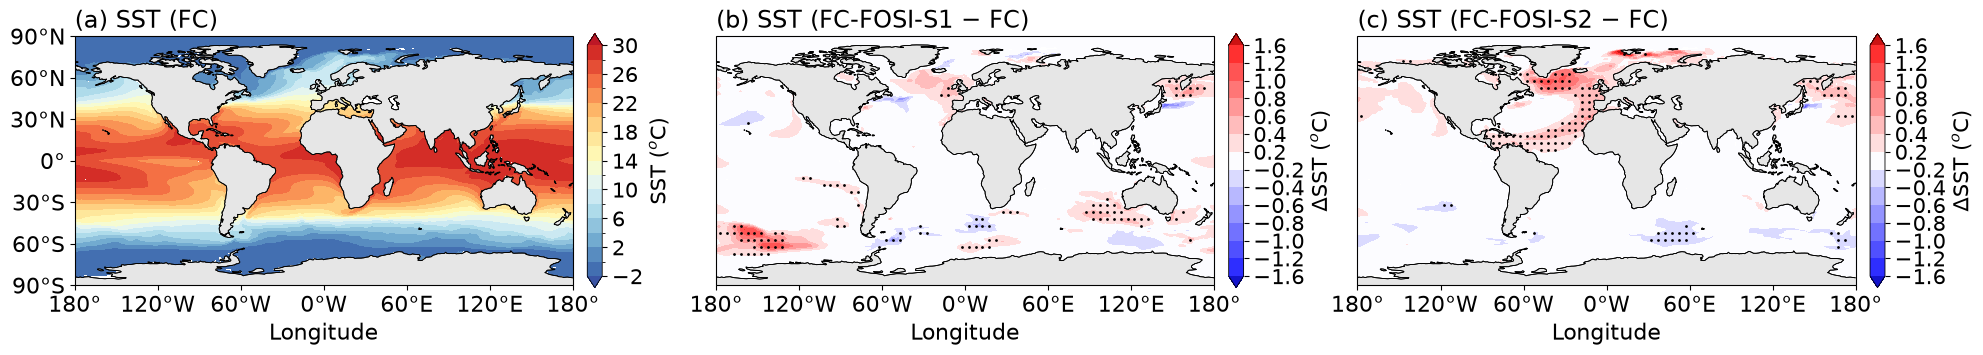

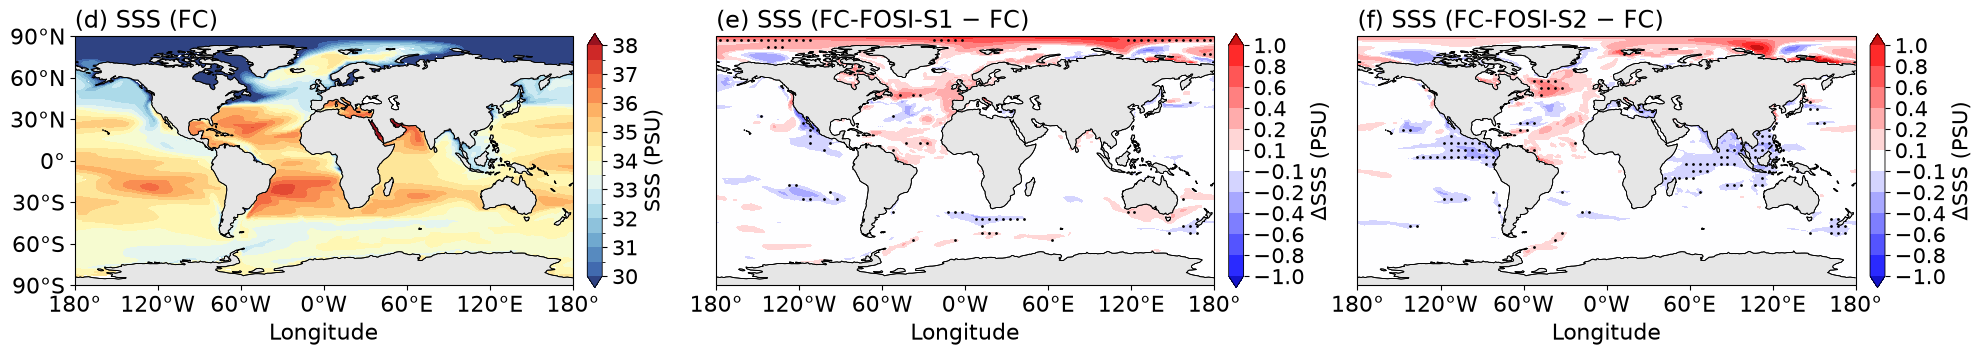

In [5]:
sfc_plotters, sfc_plot_kw = {}, {}
for vname, cfg in SURFACE.items():
    file_key = f"mpaso_ANN_{climo_token(*CLIM_YEARS)}_climo.nc"
    plotter = Surface2DClimoPlotter(
        root_dir=MODEL_ROOT, sub_dir=None, file_key=file_key, engine=ENGINE, dtype=DTYPE,
        target_res=(0.5, 0.5), area_weighted=True, use_cartopy=True,
    )
    for case, label in zip(CASES, LABELS):
        if CLIMO_OK[case]:
            plotter.add_experiment(exp=case, var_prefer=cfg["var"], label=label, year_token=YEAR_TOKEN,
                                   sub_dir=mpas_analysis_subdir(f"clim/mpas/avg/remapped/{cfg['remap']}"))
        else:
            decades = [(y, y + DECADE_LEN - 1) for y in range(CLIM_YEARS[0], CLIM_YEARS[1], DECADE_LEN)]
            plotter.add_experiment_mean(
                exp=case, label=label, var=cfg["var"],
                files=[f"{DECADAL_DIR}/{case}_ANN_{climo_token(*d)}_climo.nc" for d in decades])
            print(f"{vname} {label}: mean of {len(decades)} decadal climatologies in {DECADAL_DIR}")
    if SIG_TEST:
        plotter.add_control_climo(
            CTRL_EXP,
            [f"mpaso_ANN_{climo_token(*w)}_climo.nc" for w in CTRL_WINDOWS],
            f"post/analysis/mpas_analysis/*/clim/mpas/avg/remapped/{cfg['remap']}",
            cfg["var"],
        )

    cache_nc = os.path.join(DATA_DIR, f"{file_key}_cache_{vname}_ANN.nc")
    plotter.save_surface2d_cache(cache_nc, fields=("annual_mean",))
    print("Saved cache:", cache_nc)

    kw = dict(
        MAP_STYLE,
        var_label=vname,
        ref_idx=REF_IDX,
        tgt_idx=TGT_IDX,
        fig_idx=cfg["fig_idx"],
        clevs=cfg["clevs"],
        cbar_tick_every=cfg["cbar_tick_every"],
        diff_clevs=cfg["diff_clevs"],
        cbar_label=f"{vname} ({cfg['unit']})",
        diff_label=f"$\\Delta${vname} ({cfg['unit']})",
        sig_test=SIG_TEST,
        sig_method=SIG_METHOD,
        sig_alpha=SIG_ALPHA,
        sig_fdr=SIG_FDR,
        sig_min_diff=min(l for l in cfg["diff_clevs"] if l > 0) if SIG_MIN_LEVEL else None,
        **cfg["plot"],
    )
    out = os.path.join(FIG_DIR, f"{file_key}_compare_{vname}_ANN.pdf")
    plotter.plot_map_compare(**kw, save=out)
    sfc_plotters[vname], sfc_plot_kw[vname] = plotter, kw
    print("web:", out.replace(OUTPUT_ROOT, OUTPUT_URL))

publish(FIG_DIR, DATA_DIR)

## 2 AMOC
Atlantic MOC streamfunction from the monthly MPAS-Analysis MOC time series, averaged over `CLIM_YEARS` (exact for every experiment: computed here from the monthly values).
### Settings

In [6]:
AMOC_STYLE = dict(                            # also the base style of the global MOC figure (section 4)
    field="annual_mean",
    depth_coord="depth",
    lat_coord="lat",
    depth_units="km",
    figsize=(48, 8),
    fontz=36.0,
    wspace=0.18,
    extend="both",
    # white band below the typical smallest significant difference (median 0.4 Sv AMOC, 0.6 Sv global);
    # largest |difference| 1.0 Sv (AMOC) and 2.1 Sv (global), same levels for both MOC figures
    diff_clevs=[-2, -1.5, -1, -0.6, -0.4, -0.2, 0.2, 0.4, 0.6, 1, 1.5, 2],
    diff_cmap="bwr",
    diff_extend="both",
    diff_tick_every=1,                       # label every (non-uniform) difference level
    sig_grid=(72, 36),                       # stipple dots per panel (lat x depth), as on the maps
    sig_dot_size=16.0,                       # dot size (points²; the 48-in figure is drawn twice as large)
)

AMOC = dict(
    var="mocAtlantic",                       # variable in mocTimeSeries_*.nc
    label="AMOC",
    unit="Sv",
    fig_idx=7,                               # panels (g)-(i) (this plotter counts from 1)
    cmap="RdYlBu_r",
    clevs=list(range(-2, 13)),
    tick_every=2,                            # label every 2 Sv
    lat_band=(-34.0, 90.0),
)

### Compute & plot

/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/dask/_task_spec.py:767: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return self.func(*new_argspec, **kwargs)
/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/dask/_task_spec.py:767: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return self.func(*new_argspec, **kwargs)
/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/dask/_task_spec.py:767: FutureWarning: Usage of 'u

Saved cache: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ocn_map/amoc_cache_0001-0350.nc


/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_map/mocTimeSeries_compare_AMOC_ANN_climo_diff.pdf


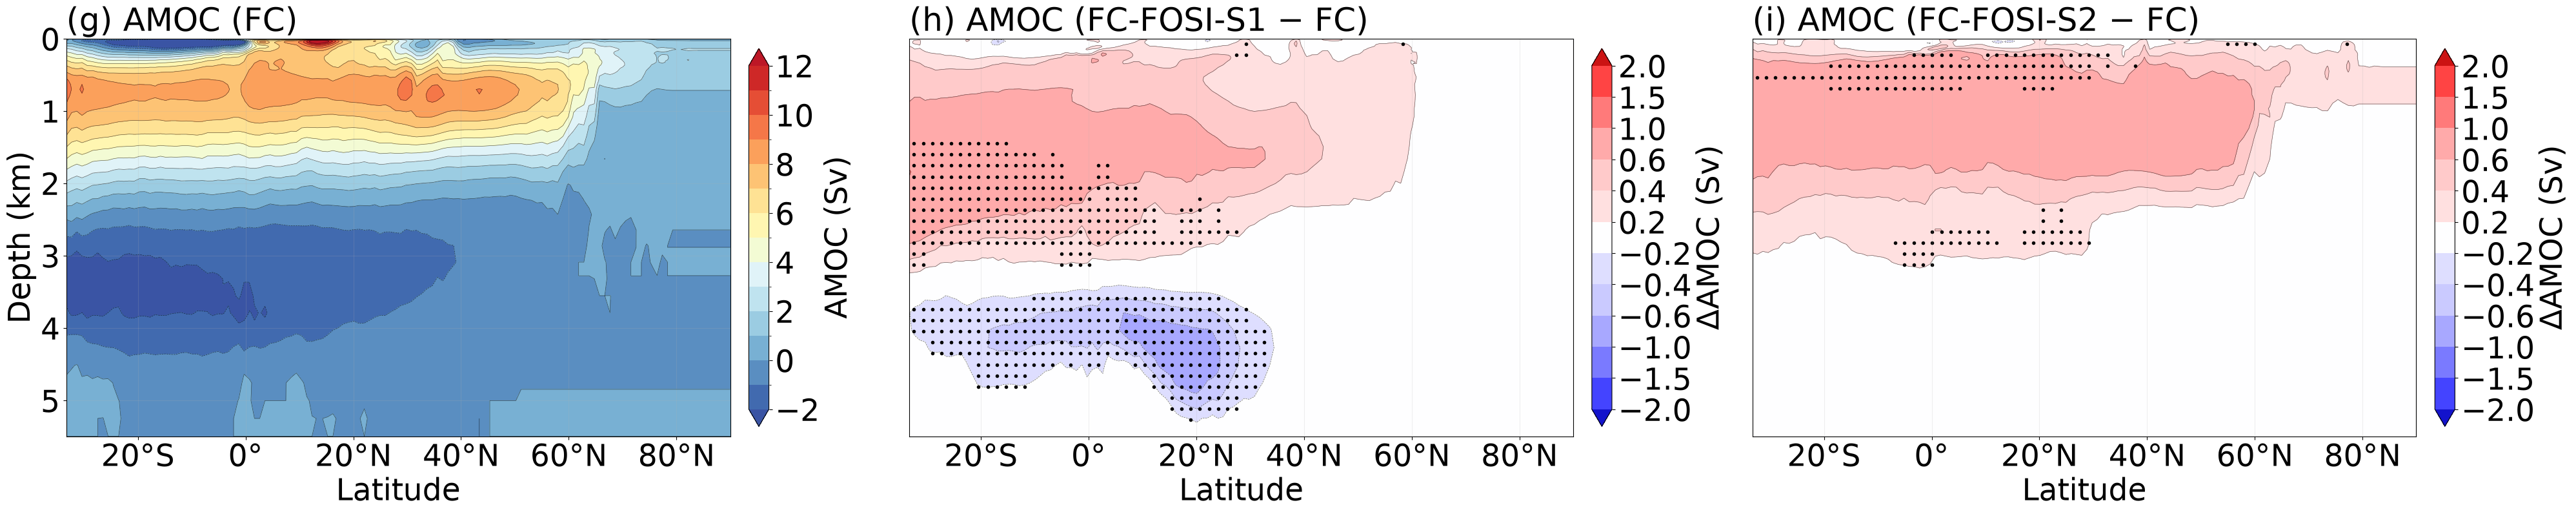

In [7]:
amoc_plotter = AMOCClimoPlotter(
    root_dir=MODEL_ROOT, sub_dir=None, file_key="mocTimeSeries", var_mpas=AMOC["var"],
    engine=ENGINE, chunks={"Time": 240}, dtype=DTYPE,
)
for case, label in zip(CASES, LABELS):
    amoc_plotter.add_experiment(
        exp=case, label=label, year_token=YEAR_TOKEN, sub_dir=mpas_analysis_subdir("timeseries/moc"),
        clim_start=f"{CLIM_YEARS[0]:04d}-01-01", clim_end=f"{CLIM_YEARS[1]:04d}-12-31",
    )

if SIG_TEST:   # piControl Atlantic MOC climatologies (clean CLIMO_LEN-yr means, checked against its time series);
               # same levels as the time series but labelled by layer midpoints -> align by level index
    amoc_plotter.add_control_climo(CTRL_EXP, [f"{y0:04d}-{y1:04d}" for y0, y1 in CTRL_WINDOWS],
                                   region="Atlantic", level_aligned=True)

cache_nc = os.path.join(DATA_DIR, f"amoc_cache_{YEAR_TOKEN}.nc")
amoc_plotter.save_amoc_cache(
    cache_nc, fields=("annual_mean", "seasonal_amplitude", "month_of_max", "monthly_climatology"),
)
print("Saved cache:", cache_nc)

amoc_plot_kw = dict(
    AMOC_STYLE,
    varnam=AMOC["label"],
    ref_idx=REF_IDX,
    tgt_idx=TGT_IDX,
    fig_idx=AMOC["fig_idx"],
    cmap=AMOC["cmap"],
    clevs=AMOC["clevs"],
    tick_every=AMOC["tick_every"],
    lat_band=AMOC["lat_band"],
    cbar_label=f"{AMOC['label']} ({AMOC['unit']})",
    diff_label=fr"$\Delta${AMOC['label']} ({AMOC['unit']})",
    sig_test=SIG_TEST,
    sig_method=SIG_METHOD,
    sig_alpha=SIG_ALPHA,
    sig_fdr=SIG_FDR,
    sig_min_diff=min(l for l in AMOC_STYLE["diff_clevs"] if l > 0) if SIG_MIN_LEVEL else None,
)
out = os.path.join(FIG_DIR, "mocTimeSeries_compare_AMOC_ANN_climo_diff.pdf")
amoc_plotter.plot_amoc_2d_compare(**amoc_plot_kw, save=out)

publish(FIG_DIR, DATA_DIR)
print("web:", out.replace(OUTPUT_ROOT, OUTPUT_URL))

## 3 Combined paper figure: SST (a–c), SSS (d–f), AMOC (g–i)
The three rows are redrawn with the levels, colours and significance of sections 1–2 and then placed on one grid (`arrange_panel_grid`): all nine panels have the same size and 2:1 shape (the global-map shape; the AMOC panels get the same box), columns line up, row gaps are equal, all rows use the same font size, and each row has one colorbar for the reference and one shared by its two difference panels. Needs sections 1 and 2 to have run.
### Settings

In [8]:
COMBINED = dict(                # all lengths in inches
    width=24.0,                 # figure width; the height follows from the panel shape
    aspect=0.5,                 # panel height / width (global lat-lon maps)
    fontz=16.0,                 # tick-label size of every row
    left=1.2,                   # room for the latitude / depth labels
    col_gaps=(1.7, 0.7),        # after the reference column (its colorbar) / between the difference panels
    right=1.7,                  # after the last column (shared difference colorbar)
    top=0.6,
    row_gap=1.3,                # room for x labels and the next row's titles
    bottom=0.9,
    cbar_frac=0.95,             # colorbar height / panel height
    print_width=6.5,            # width of the figure in the paper (LaTeX \textwidth): fonts, lines and
    print_dot=1.0,              #   dots shrink by print_width / width; print_dot = dot diameter there (pt)
    sig_grid=(72, 36),          # stipple dots per panel, same in every row
)

### Plot

/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_map/ocn_map_compare_SST_SSS_AMOC_ANN.pdf


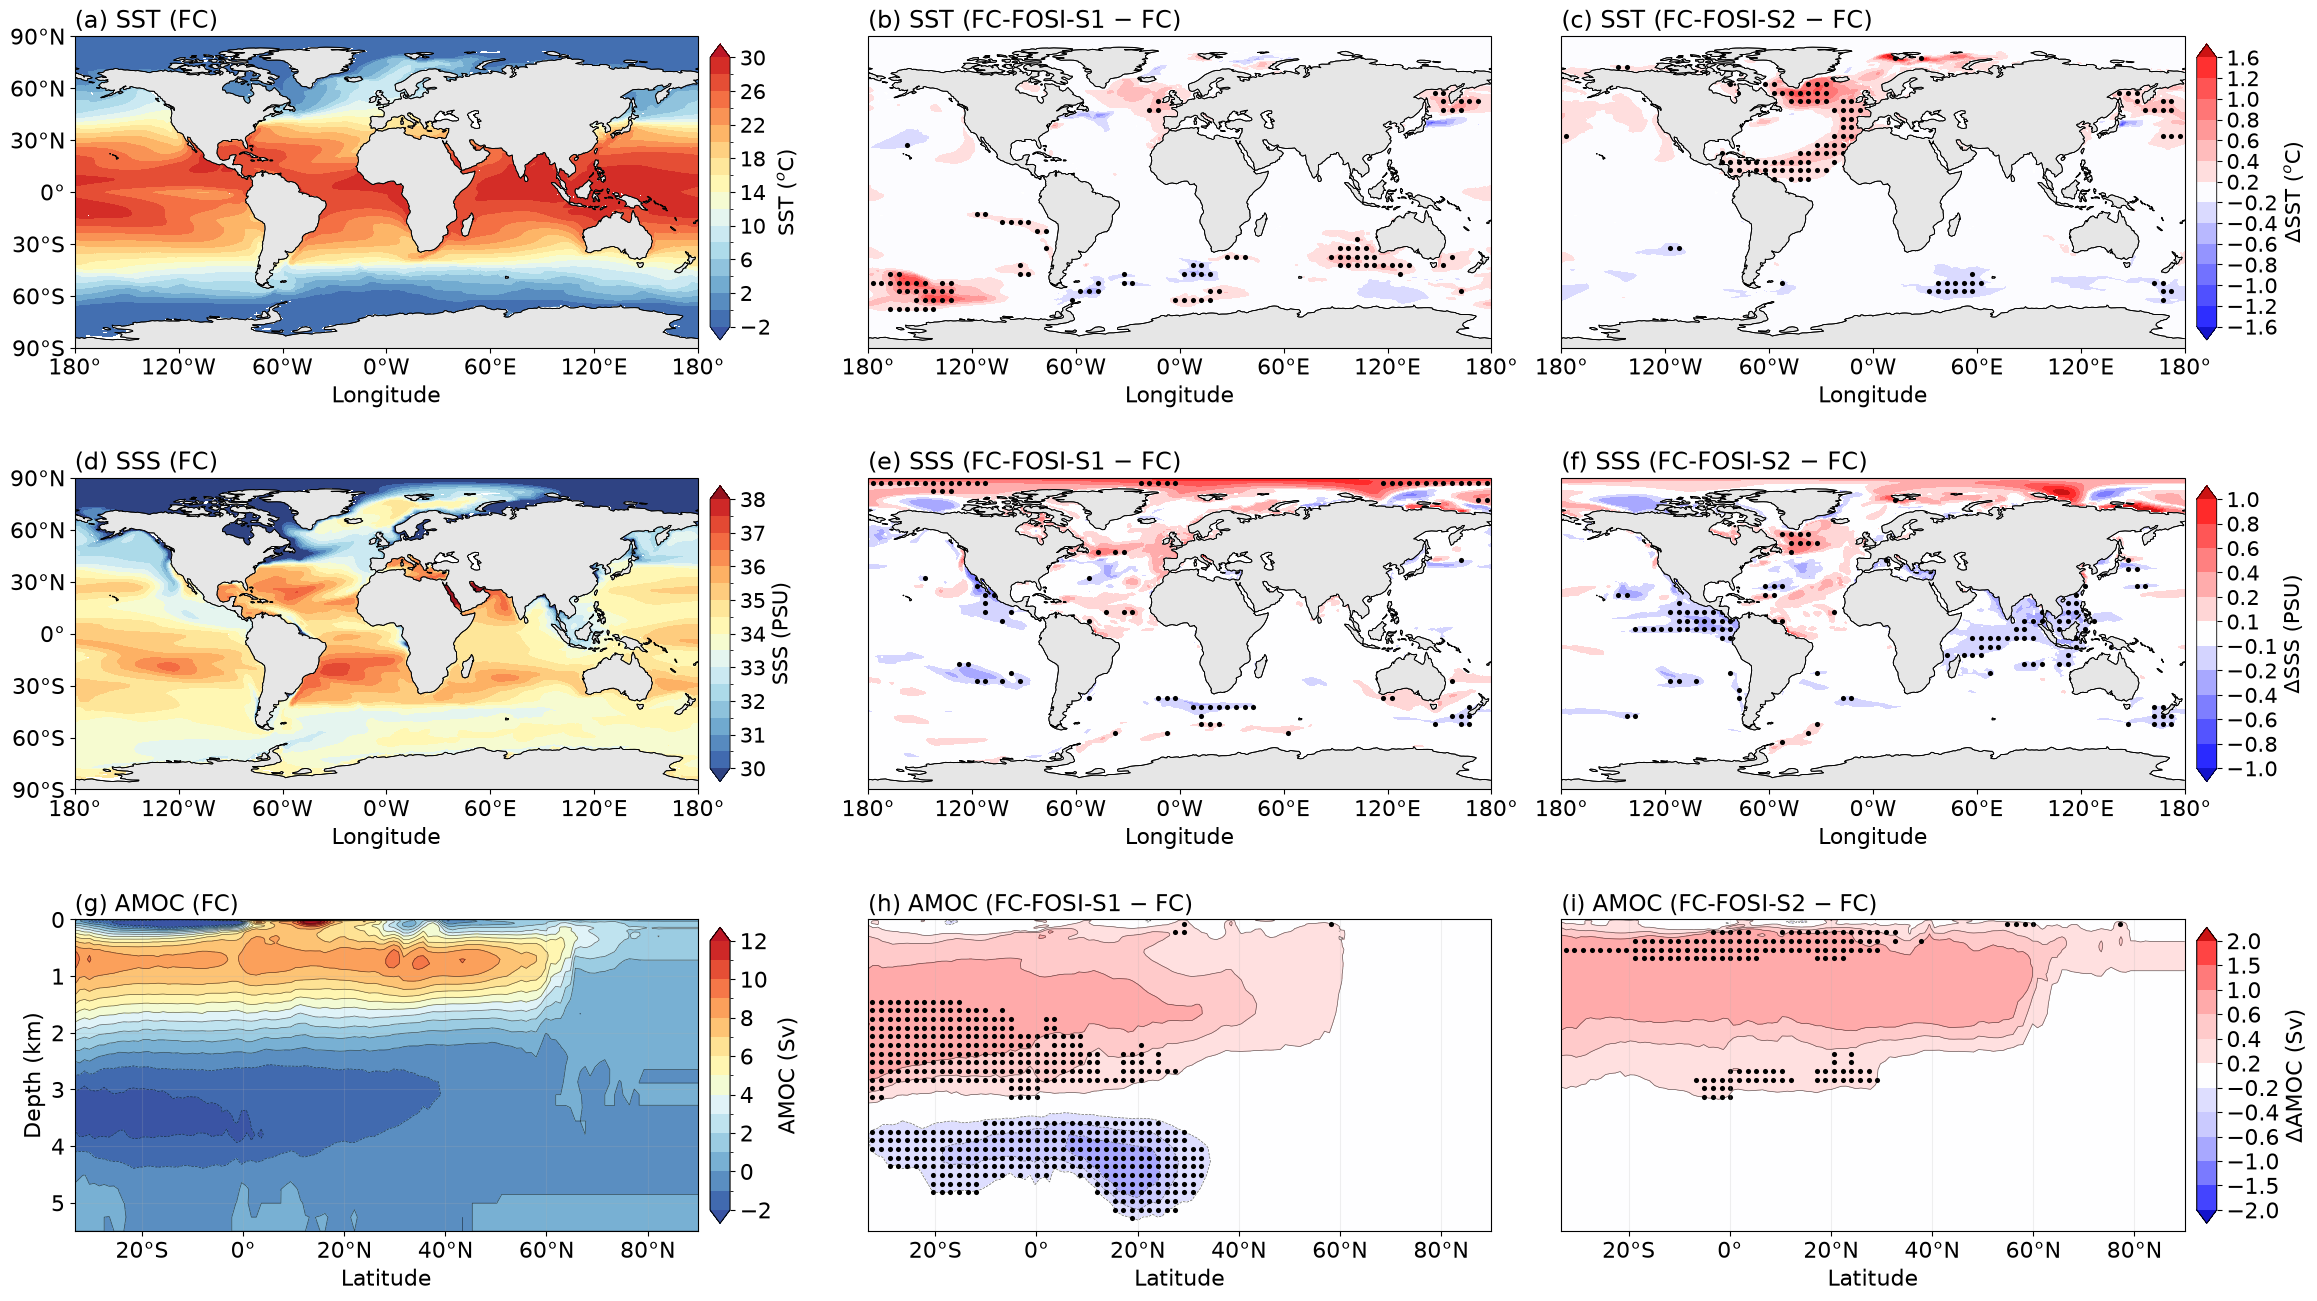

In [9]:
# stipple dots of print_dot pt diameter once the figure is scaled to print_width, same grid in all rows
dots = dict(sig_grid=COMBINED["sig_grid"],
            sig_dot_size=(COMBINED["print_dot"] * COMBINED["width"] / COMBINED["print_width"]) ** 2)
layout = {k: COMBINED[k] for k in ("width", "aspect", "left", "col_gaps", "right", "top", "row_gap",
                                   "bottom", "cbar_frac")}

fig = plt.figure()
slots = fig.add_gridspec(3, 1)          # provisional; arrange_panel_grid sets the final positions
for row, vname in enumerate(("SST", "SSS")):
    sfc_plotters[vname].plot_map_compare(**{**sfc_plot_kw[vname], "fontz": COMBINED["fontz"], **dots},
                                         diff_cbar="shared", fig=fig, slot=slots[row])
# the AMOC plotter sizes ticks at 0.95 * fontz (maps: 1.0) -> scale so all rows match
amoc_plotter.plot_amoc_2d_compare(**{**amoc_plot_kw, "fontz": COMBINED["fontz"] / 0.95, **dots},
                                  diff_cbar="shared", box_aspect=COMBINED["aspect"], fig=fig, slot=slots[2])
arrange_panel_grid(fig, [sfc_plotters["SST"].last_axes, sfc_plotters["SSS"].last_axes, amoc_plotter.last_axes],
                   **layout)

comb_out = os.path.join(FIG_DIR, "ocn_map_compare_SST_SSS_AMOC_ANN.pdf")
fig.savefig(comb_out, dpi=300, bbox_inches="tight")

publish(FIG_DIR, DATA_DIR)
print("web:", comb_out.replace(OUTPUT_ROOT, OUTPUT_URL))

## 4 Global MOC (separate figure)
The MOC time series hold only the Atlantic, so the global overturning streamfunction is read from the MPAS-Analysis annual-mean MOC climatology (`clim/mpas/avg/mocStreamfunction_years<clim>.nc`, variable `mocGlobal`) for the same `CLIM_YEARS`. Same layout and base style as the AMOC figure (`AMOC_STYLE`): FC, then FC-FOSI − FC.
### Settings

In [10]:
GMOC = dict(
    region="Global",                         # mocGlobal / latGlobal in the climatology file
    label="Global MOC",
    unit="Sv",
    fig_idx=0, #AMOC["fig_idx"] + 3,             # continue the panel lettering of the AMOC figure
    cmap="RdBu_r",
    clevs=list(range(-20, 21, 2)),           # strong near-surface cells saturate (extend="both")
    tick_every=2,                            # label every other level (every 4 Sv)
    lat_band=None,                           # full latitude range
    cbar_labelpad=12,                        # colorbar label further from the ticks
)

### Compute & plot

web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_map/mocStreamfunction_compare_MOCGlobal_ANN_climo_diff.pdf


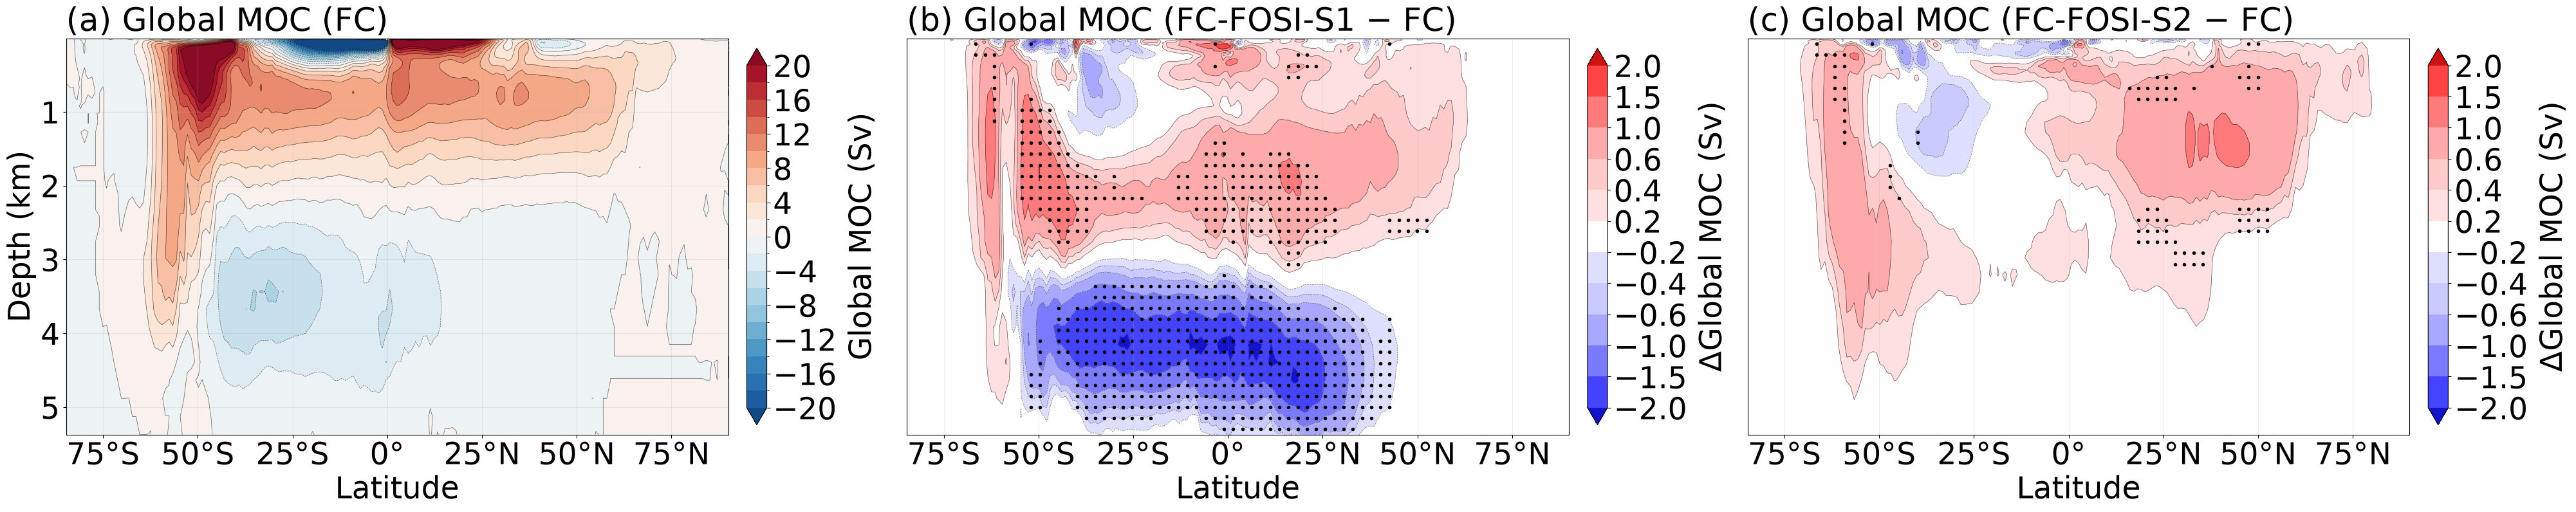

In [11]:
bad = [label for case, label in zip(CASES, LABELS) if not CLIMO_OK[case]]
if bad:
    print(f"WARNING: the MPAS-Analysis global MOC climatology of {', '.join(bad)} is not the {CLIM_YEARS} mean "
          "(other years averaged in, see the Derived cell); no replacement exists on disk.")
clim_years = f"{CLIM_YEARS[0]:04d}-{CLIM_YEARS[1]:04d}"
gmoc_plotter = AMOCClimoPlotter(root_dir=MODEL_ROOT, sub_dir=None, engine=ENGINE, dtype=DTYPE)
for case, label in zip(CASES, LABELS):
    gmoc_plotter.add_experiment_climo(exp=case, label=label, sub_dir=mpas_analysis_subdir("clim/mpas/avg"),
                                      years=clim_years, region=GMOC["region"])
if SIG_TEST:
    gmoc_plotter.add_control_climo(CTRL_EXP, [f"{y0:04d}-{y1:04d}" for y0, y1 in CTRL_WINDOWS],
                                   region=GMOC["region"])

gmoc_plot_kw = dict(
    AMOC_STYLE,
    varnam=GMOC["label"],
    ref_idx=REF_IDX,
    tgt_idx=TGT_IDX,
    fig_idx=GMOC["fig_idx"],
    cmap=GMOC["cmap"],
    clevs=GMOC["clevs"],
    tick_every=GMOC["tick_every"],
    lat_band=GMOC["lat_band"],
    cbar_labelpad=GMOC["cbar_labelpad"],
    cbar_label=f"{GMOC['label']} ({GMOC['unit']})",
    diff_label=fr"$\Delta${GMOC['label']} ({GMOC['unit']})",
    sig_test=SIG_TEST,
    sig_method=SIG_METHOD,
    sig_alpha=SIG_ALPHA,
    sig_fdr=SIG_FDR,
    sig_min_diff=min(l for l in AMOC_STYLE["diff_clevs"] if l > 0) if SIG_MIN_LEVEL else None,
)
out = os.path.join(FIG_DIR, "mocStreamfunction_compare_MOCGlobal_ANN_climo_diff.pdf")
gmoc_plotter.plot_amoc_2d_compare(**gmoc_plot_kw, save=out)

publish(FIG_DIR, DATA_DIR)
print("web:", out.replace(OUTPUT_ROOT, OUTPUT_URL))